In [12]:
import zipfile

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Copy of devnagari digit.zip"
extract_path= "/content/drive/MyDrive/AI and Machine Learning"

with  zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os
import numpy as np
from PIL import Image

Load & Preprocess Data (PIL method)

In [15]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Dataset paths
train_dir = "/content/drive/MyDrive/AI and Machine Learning/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI and Machine Learning/DevanagariHandwrittenDigitDataset/Test"

img_size = 28

def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images(train_dir)
x_test, y_test = load_images(test_dir)

# Reshape
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(x_train.shape, y_train.shape)

(17000, 28, 28, 1) (17000, 10)


Build FCN Model

In [16]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),

    layers.Dense(64, activation='sigmoid'),
    layers.Dense(128, activation='sigmoid'),
    layers.Dense(256, activation='sigmoid'),

    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [18]:
from sklearn.utils import shuffle

# Shuffle data
x_train, y_train = shuffle(x_train, y_train, random_state=42)

# Train model
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4327 - loss: 1.8587 - val_accuracy: 0.7182 - val_loss: 1.0824
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8102 - loss: 0.6632 - val_accuracy: 0.8356 - val_loss: 0.4486
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8835 - loss: 0.3642 - val_accuracy: 0.9147 - val_loss: 0.3106
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9255 - loss: 0.2587 - val_accuracy: 0.9371 - val_loss: 0.2269
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9449 - loss: 0.1916 - val_accuracy: 0.9500 - val_loss: 0.1755
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9558 - loss: 0.1506 - val_accuracy: 0.9591 - val_loss: 0.1448
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9693 - loss: 0.1184 - val_accuracy: 0.9632 - val_loss: 0.1260
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9735 - loss: 0.0987 - val_accuracy: 0.

Evaluate Model

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9780 - loss: 0.0847
Test Accuracy: 0.9779999852180481


Save & Load Model

In [20]:
# Save model (NEW FORMAT)
model.save("devnagari_model.keras")

# Load model
from tensorflow.keras.models import load_model
loaded_model = load_model("devnagari_model.keras")

# Evaluate to initialize metrics
loaded_model.evaluate(x_test, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9780 - loss: 0.0847


[0.08469272404909134, 0.9779999852180481]

Predictions

In [21]:
import numpy as np

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[0])
print("Actual:", np.argmax(y_test[0]))

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 0
Actual: 0


Plot Accuracy & Loss

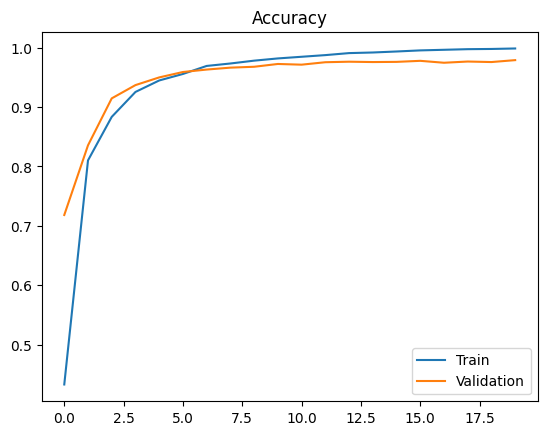

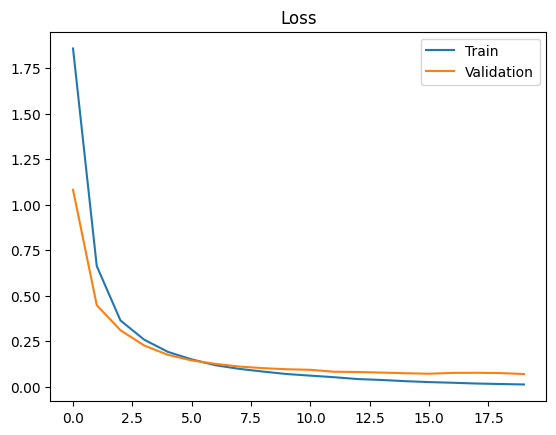

In [22]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()